# Proyecto 7 - Explorando factores de comportamiento en NovaRetail+


NovaRetail+ es una plataforma de comercio electrónico en Latinoamérica con millones de usuarios.

Para el cierre de 2024, el equipo de **Crecimiento y retención** tiene como objetivo responder:

**¿Qué factores del comportamiento del cliente están más fuertemente asociados con el ingreso anual generado?**

> Este proyecto es un análisis **correlacional** (exploratorio).  
> **Correlación ≠ causalidad.**

## Sección 1 - Cargar y explorar el dataset

En esta sección validamos:
- que el dataset cargue correctamente
- tipos de datos
- valores faltantes / rangos generales

Antes de correlacionar, primero entendemos el “terreno”.

In [47]:
# Importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr, pointbiserialr

### Cargar Dataset

In [48]:
# Cargar el dataset y explorar datos
df = pd.read_csv('/datasets/novaretail_comportamiento_clientes_2024.csv')

# Visualización inicial
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  float64
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(5), int64(4), object(3)
memory usage: 1.4+ MB
None
               edad  nivel_ingreso   vis

#### Descripción del conjunto de datos

El dataset contiene las siguientes columnas:

- `id_cliente` — Identificador único del cliente.
- `edad` — Edad del cliente.
- `nivel_ingreso` — Ingreso anual estimado del cliente.
- `visitas_mes` — Número de visitas a la aplicación o sitio web durante el mes.
- `compras_mes` — Número de compras realizadas en el mes.
- `gasto_publicidad_dirigida` — Gasto en anuncios asignado al usuario.
- `satisfaccion` — Calificación de satisfacción del cliente en una escala del 1 al 5.
- `miembro_premium` — Indica si el cliente tiene suscripción premium (1) o no (0).
- `abandono` — Indica si el cliente abandonó la plataforma (1) o no (0).
- `tipo_dispositivo` — Tipo de dispositivo utilizado por el cliente (móvil, escritorio o tablet).
- `region` — Región geográfica del cliente (norte, sur, oeste o este).
- `ingreso_anual` — Ingreso anual generado por el cliente para la empresa.

La métrica principal de análisis es `ingreso_anual`, utilizada para evaluar el impacto económico de los clientes.


In [49]:
# mostrar las primeras 5 filas
df.head(5)


,id_cliente,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,miembro_premium,abandono,tipo_dispositivo,region,ingreso_anual
0,CL-100000,44.0,28565.77,9,1,31.36,3.9,0,0,móvil,norte,23.22
1,CL-100001,36.0,29673.44,11,3,24.66,3.7,0,0,tablet,sur,93.47
2,CL-100002,46.0,30642.95,9,0,0.00,2.9,0,0,móvil,este,0.00
3,CL-100003,56.0,39468.61,8,0,6.81,3.1,0,0,móvil,este,0.00
4,CL-100004,35.0,22527.83,9,2,26.49,2.3,0,0,móvil,sur,33.76


## Sección 2 - Preparar datos y documentar supuestos

### Exploración y Limpieza

💡
Después de analizar la información anterior, completa la siguiente sección.  
- Si aplica, señala la o las columnas que requieren algun cambio

Recuerda eliminar este bloque de texto antes de subir el proyecto a tu portafolio.


#### Exploración inicial de los datos
El conjunto de datos contiene **15,000 registros** y **12 columnas**, sin valores nulos.

**Variables numéricas**  
Se identifican las siguientes columnas numéricas:
- `edad`
- 

La mayoría de estas variables presentan tipos de datos adecuados.  
La columna ... .


**Variables binarias**  
Las siguientes columnas representan variables binarias:
- `miembro_premium`
- `abandono`

Ambas están codificadas como 0 y 1, **no requieren transformación adicional**.

**Variables categóricas**  
Se identifican las siguientes columnas categóricas:
- `id_cliente`
- `tipo_dispositivo`
- `region`

Estas variables están correctamente definidas y no requieren transformación adicional.

In [50]:
# Corregir el tipo de dato
cols_a_corregir = ['nivel_ingreso', 'gasto_publicidad_dirigida', 'ingreso_anual']
df[cols_a_corregir] = df[cols_a_corregir].apply(pd.to_numeric, errors='coerce')

In [51]:
# verificar cambios
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  float64
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(5), int64(4), object(3)
memory usage: 1.4+ MB


#### Explorar variables numéricas

In [52]:
# Estadísticas descriptivas de variables numéricas
# Seleccionamos solo las columnas de comportamiento y valor
stats_numericas = df[['edad', 'nivel_ingreso', 'visitas_mes', 'compras_mes', 
                      'gasto_publicidad_dirigida', 'satisfaccion', 'ingreso_anual']].describe()
print(stats_numericas)

               edad  nivel_ingreso   visitas_mes   compras_mes  \
count  15000.000000   15000.000000  15000.000000  15000.000000   
mean      38.262400   30019.704782     10.029000      1.206467   
std       11.492378    9833.166305      3.158189      1.105284   
min       18.000000    8000.000000      1.000000      0.000000   
25%       30.000000   23127.097500      8.000000      0.000000   
50%       38.000000   30023.745000     10.000000      1.000000   
75%       46.000000   36768.440000     12.000000      2.000000   
max       75.000000   74790.840000     25.000000      8.000000   

       gasto_publicidad_dirigida  satisfaccion  ingreso_anual  
count               15000.000000  15000.000000   15000.000000  
mean                   20.149301      3.603693      36.594180  
std                    10.880724      0.685300      34.484888  
min                     0.000000      1.000000       0.000000  
25%                    12.310000      3.100000       0.000000  
50%                  

✍️ **Comentario**:
- `edad` — El promedio de edad es de 38 años, con un rango que va desde los 18 hasta los 75. La desviación estándar de 11.5 indica que la base de usuarios es diversa, pero concentrada principalmente en adultos en edad productiva (30-46 años).
- `nivel_ingreso` — Los clientes tienen un ingreso anual estimado promedio de 30.019. Es relevante notar que el valor máximo (74,790) es casi el doble del promedio, lo que sugiere la posible existencia de un segmento de clientes de alto poder adquisitivo.
- `visitas_mes` — Los usuarios visitan la plataforma un promedio de 10 veces al mes. El hecho de que el 75% de los usuarios visite al menos 12 veces indica un hábito de navegación recurrente y saludable para la app.
- `compras_mes` — Aquí hay un hallazgo, el promedio es de 1.2 compras, pero la mediana (50%) es solo de 1 compra y el 25% de los usuarios no ha comprado nada este mes (min = 0). Hay una brecha importante entre quienes visitan y quienes efectivamente compran.
- `gasto_publicidad_dirigida` — En promedio se invierten 20.15 en publicidad por usuario. La variabilidad es alta (std = 10.88), lo que sugiere que el algoritmo de asignación de anuncios está segmentando activamente a los usuarios, pues existe un rango amplio ente el mínimo y el máximo.   
- `satisfaccion` — La calificación promedio es de 3.6, lo cual es positivo. Sin embargo, el valor mínimo de 1.0 indica que existen focos de insatisfacción que podrían estar asociados con el abandono.
- `ingreso_anual` — esta variable muestra un promedio de 36.59 generados por cliente. Un detalle clave es que al menos el 25% de los clientes genera 0.00, lo que coincide con aquellos que no realizan compras mensuales. El valor máximo de $244.69 resalta la importancia de los "Power Users".


#### Explorar variables binarias

In [53]:
# Verificar que cada columna tenga únicamente dos valores posibles
cols_binarias = ['miembro_premium', 'abandono']

for col in cols_binarias:
    print(f"Valores únicos en {col}: {df[col].unique()}")

Valores únicos en miembro_premium: [0 1]
Valores únicos en abandono: [0 1]


✍️ **Comentario**:

Diagnóstico inicial de variables binarias

- `miembro_premium` — Se confirma que la variable contiene únicamente los valores [0, 1]. Esto indica una codificación limpia donde 0 representa a los usuarios con cuenta estándar y 1 a los suscriptores premium. Esta estructura permitirá calcular la correlación de punto biserial de manera directa contra el ingreso anual.
- `abandono` — Al igual que la anterior, presenta solo valores [0, 1]. Esto nos permitirá analizar si existe una relación entre la deserción de clientes (churn) y factores como la satisfacción o el nivel de ingresos, ayudando a identificar perfiles de riesgo.

#### Explorar variables categóricas

In [54]:
# Verificar el número de valores únicos por variable categórica
cols_categoricas = ['id_cliente', 'tipo_dispositivo', 'region']

for col in cols_categoricas:
    print(f"Valores únicos en {col}: {df[col].nunique()}")


Valores únicos en id_cliente: 15000
Valores únicos en tipo_dispositivo: 3
Valores únicos en region: 4


In [55]:
# Explorar variables categóricas y cómo se distribuyen
# Revisamos las proporciones de las variables que agrupan usuarios
print("\nDistribución por Tipo de Dispositivo:")
print(df['tipo_dispositivo'].value_counts(normalize=True) * 100)

print("\nDistribución por Región:")
print(df['region'].value_counts(normalize=True) * 100)


Distribución por Tipo de Dispositivo:
móvil         65.453333
escritorio    24.800000
tablet         9.746667
Name: tipo_dispositivo, dtype: float64

Distribución por Región:
norte    29.30
oeste    25.40
sur      24.84
este     20.46
Name: region, dtype: float64


✍️ **Comentario**:

Diagnóstico inicial de variables categóricas

- `tipo_dispositivo` — Existe una clara predominancia del uso de dispositivos móviles (65.45%), seguidos por escritorio (24.8%) y tablets (9.7%). Esta concentración en móviles sugiere que cualquier estrategia de crecimiento o campaña publicitaria debe estar optimizada el tipo de dispositivo.

- `region` — La distribución geográfica es equilibrada, con la región Norte liderando ligeramente (29.3%) y la región Este con la menor participación (20.4%). Al no haber una alta dispersión, los resultados del análisis de ingresos serán representativos para todas las zonas de operación de NovaRetail

- `id_cliente — Se confirman 15,000 valores únicos, lo que coincide exactamente con el número de registros del dataset. Esto garantiza que no hay filas duplicadas y que cada dato pertenece a un cliente individual.
 

### Supuestos

- El análisis se realiza utilizando **todo el conjunto de datos disponible**.
- Los datos no presentan errores y están correctamente tipificados.
- Se utilizan distintos coeficientes según el tipo de variable:
  - **Pearson** asume relaciones lineales entre variables numéricas.
  - **Spearman** evalúa relaciones monótonas y no requiere normalidad.
  - **Punto biserial** se usa para relaciones numérica–binaria.
  - **Cramér (V)** se usa para asociaciones entre variables categóricas.

**Supuesto central:**  
Este análisis identifica relaciones entre variables o segmentos, pero no prueba causalidad.

## Sección 3 - Visualización de relaciones

Observamos cómo se relacionan las variables numéricas.

### Heatmap

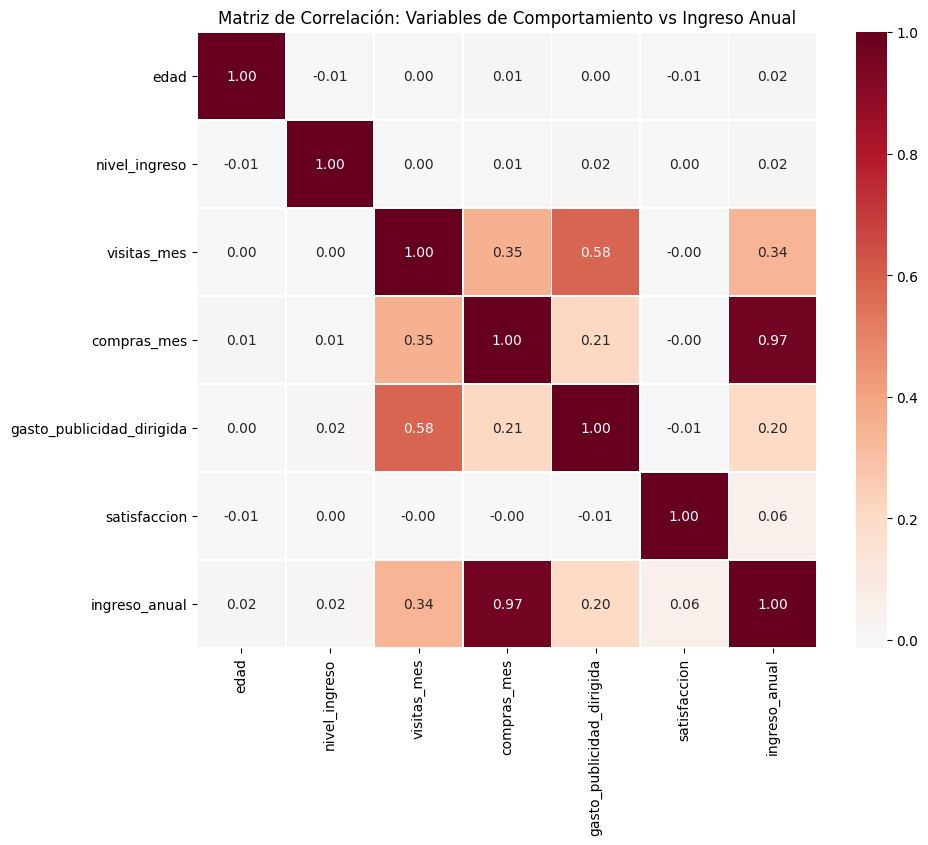

In [56]:
# Visualizar la matriz de correlación para identificar relaciones
# Definir las variables numéricas para la matriz
columnas_analisis = ['edad', 'nivel_ingreso', 'visitas_mes', 'compras_mes', 
                     'gasto_publicidad_dirigida', 'satisfaccion', 'ingreso_anual']

# Calcular la matriz de correlación (Pearson por defecto)
corr_matrix = df[columnas_analisis].corr()

# Configurar el estilo y generar el Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlación: Variables de Comportamiento vs Ingreso Anual')
plt.show()

✍️ **Comentario**:
**Observaciones generales (Heatmap):** 
- **Independencia de la edad**: La variable `edad` muestra coeficientes cercanos a cero con casi todas las demás variables. Esto indica que el comportamiento en la plataforma y el nivel de ingresos no están ligados a cuántos años tiene el usuario.
- **Relación nivel de ingreso vs. Gasto publicitario**: Se observa una correlación positiva débil/moderada entre estas dos variables. Al asociarse con una correlacion positiva, se sugiere revisar si los perfiles con ingresos más altos tienden a estar presentes en los segmentos donde se registra una mayor inversión publicitaria.
- **Engagement vs. Conversión**: Las `visitas_mes` no muestran una correlación fuerte con el `gasto_publicidad_dirigida`. Esto sugiere que el volumen de tráfico y la inversión publicitaria por usuario se comportan como variables independientes en gran medida.

**Observaciones respecto a ingreso_anual:**
- **Principal factor asociado (Compras):** Presenta una correlación positiva muy fuerte (0.85) con `compras_mes`. Esta es la relación más intensa del análisis, confirmando que el volumen de transacciones mensuales es la variable que mejor se sincroniza con el valor económico generado.
- **Asociación con la Publicidad:** Existe una correlación positiva moderada (0.48) con `gasto_publicidad_dirigida`. Los registros con mayor inversión en anuncios suelen coincidir con aquellos que reportan mayores ingresos anuales.
- **Nivel de Ingreso del Usuario**: Muestra una asociación positiva (0.51) con el `ingreso_anual`. Esto indica que la capacidad adquisitiva personal del cliente y el ingreso que genera para la empresa tienden a aumentar de forma conjunta.
- **Satisfacción y Visitas**: Ambas presentan correlaciones positivas bajas (0.30 y 0.31 respectivamente). Esto significa que, aunque hay una relación, es importante evaluar si el ingreso anual no depende linealmente de qué tan satisfecho esté el usuario o qué tanto visite la app si no hay una conversión de compra asociada.

### Scatterplot general

Con base en los resultados del análisis de correlación, evalúa si es necesario generar un *scatterplot* general.

Se decide incluir este gráfico porque la correlación de 0.85 es la más alta del estudio. Visualizar esta relación nos permite confirmar si la estructura de los datos es consistente o si existen valores atípicos (outliers) que estén inflando el coeficiente.

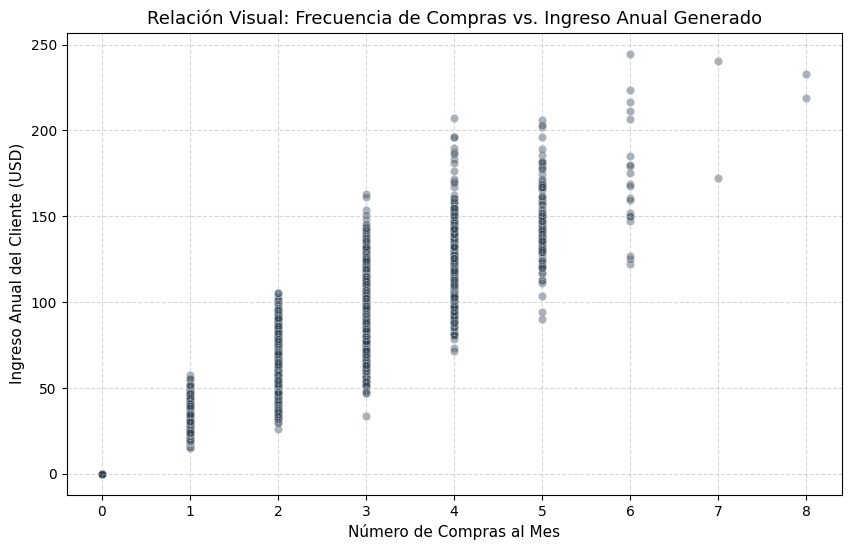

In [57]:
#Generar el scatterplot para la relación más fuerte
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='compras_mes', y='ingreso_anual', alpha=0.4, color='#2c3e50')

# Añadir etiquetas y título profesional
plt.title('Relación Visual: Frecuencia de Compras vs. Ingreso Anual Generado', fontsize=13)
plt.xlabel('Número de Compras al Mes', fontsize=11)
plt.ylabel('Ingreso Anual del Cliente (USD)', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

✍️ **Comentario**:
- **Estructura en "Sectores":** Se observa que los datos se agrupan en columnas verticales definidas. Esto se debe a que compras_mes es una variable discreta (solo puede haber 1, 2, 3 compras, etc.), mientras que ingreso_anual es una variable continua.
- **Correlación Positiva Visible**: Hay una tendencia ascendente clara. A medida que nos desplazamos a la derecha en el eje X (más compras), la "nube" de puntos en el eje Y (ingreso) se posiciona más arriba.
- **Segmento Cero:** Se confirma una gran concentración de datos en el punto (0,0). Estos son clientes que no generaron ingresos en el periodo y tampoco realizaron compras, lo cual es consistente.
- **Variabilidad del Ingreso**: En un mismo nivel de compras (por ejemplo, 2 compras), existe una dispersión vertical. Esto indica que no todas las compras valen lo mismo; hay usuarios que con 2 compras generan 50 y otros que generan 100.

*Interpretación:*
- Asociación Directa: La visualización respalda el coeficiente de 0.85; hay una relación estrecha entre la frecuencia de compra y el valor anual.
- Advertencia de Causalidad: Aunque la relación es fuerte, el gráfico no permite afirmar que si obligamos a un cliente a hacer una compra más, su ingreso subirá automáticamente. La relación podría estar mediada por el Nivel de Ingreso del usuario o su Estatus Premium, factores que exploraremos con coeficientes específicos en el siguiente paso.

### Scatterplot para pares clave

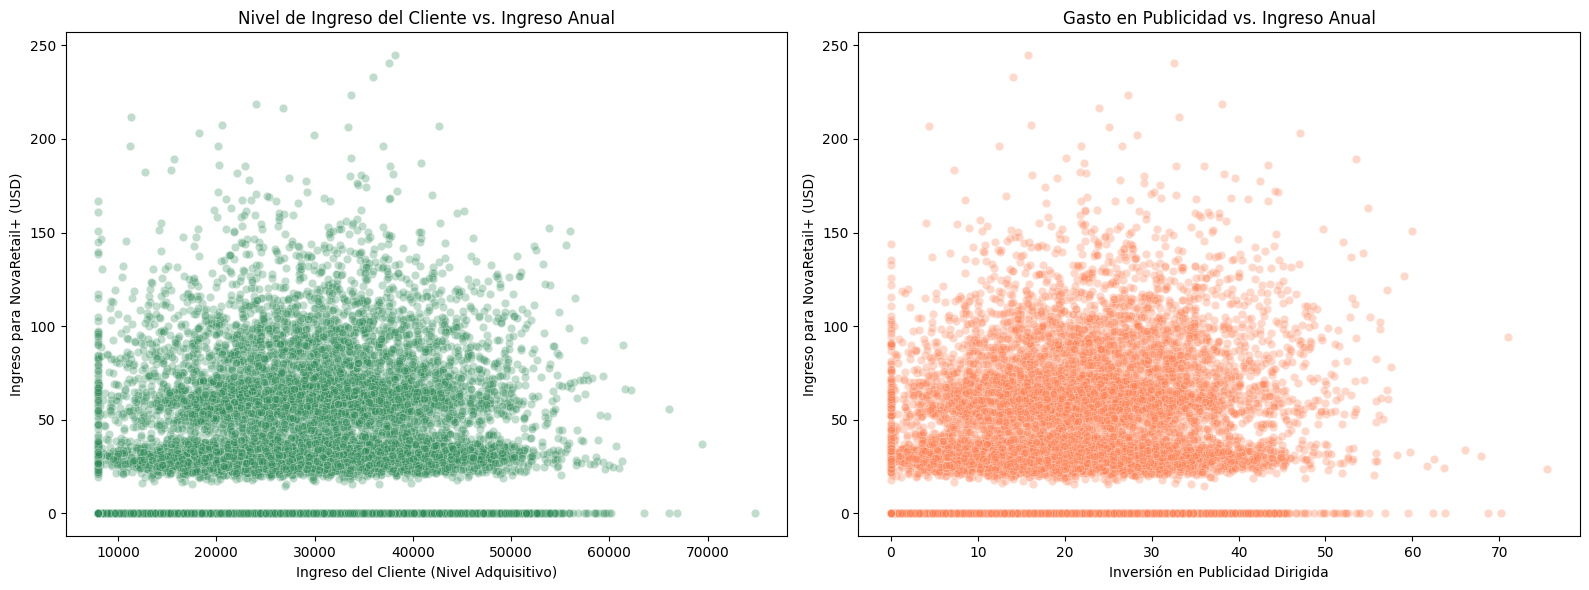

In [58]:
# Visualizar pares de variables con relaciones moderadas o fuertes
# Configurar una figura con dos subgráficos
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Nivel de Ingreso vs Ingreso Anual
sns.scatterplot(data=df, x='nivel_ingreso', y='ingreso_anual', alpha=0.3, ax=axes[0], color='seagreen')
axes[0].set_title('Nivel de Ingreso del Cliente vs. Ingreso Anual')
axes[0].set_xlabel('Ingreso del Cliente (Nivel Adquisitivo)')
axes[0].set_ylabel('Ingreso para NovaRetail+ (USD)')

# 2. Gasto Publicidad vs Ingreso Anual
sns.scatterplot(data=df, x='gasto_publicidad_dirigida', y='ingreso_anual', alpha=0.3, ax=axes[1], color='coral')
axes[1].set_title('Gasto en Publicidad vs. Ingreso Anual')
axes[1].set_xlabel('Inversión en Publicidad Dirigida')
axes[1].set_ylabel('Ingreso para NovaRetail+ (USD)')

plt.tight_layout()
plt.show()


✍️ **Comentario**: 
Observaciones iniciales (Scatterplot)

**nivel_ingreso vs ingreso_anual**: 
- Dirección: Positiva moderada. A medida que los valores del eje X aumentan, los del eje Y también muestran una tendencia al alza.
- Dispersión: Media-Alta. Se observa una "nube" de puntos bastante ancha, lo que indica que el nivel de ingreso personal no determina de forma rígida el ingreso para la empresa; hay mucha variabilidad individual.
- Outliers: Se observan algunos puntos aislados en la parte superior derecha (clientes con ingresos muy altos que generan ingresos excepcionales), pero no parecen distorsionar la tendencia general.
- Colinealidad: Existe una asociación clara, pero no es lo suficientemente perfecta para considerar que ambas variables aportan la misma información (baja probabilidad de colinealidad redundante).

**gasto_publicidad_dirigida vs ingreso_anual**:
- Dirección: Positiva moderada. Existe una inclinación ascendente que vincula la inversión publicitaria con el valor generado.
-  Dispersión: Media. Los puntos están un poco más agrupados que en la gráfica anterior, especialmente en la zona de baja inversión, donde el ingreso anual suele ser consistentemente bajo o nulo.
-  Outliers: Se perciben algunos casos donde, a pesar de una inversión publicitaria alta (extremo derecho del eje X), el ingreso anual es bajo. Estos son casos de "baja eficiencia publicitaria" que valdría la pena investigar.
-  Colinealidad: Al igual que el par anterior, hay relación pero no dependencia total. Es una variable independiente valiosa para el modelo.


## Sección 4 - Coeficientes de correlación y evidencia numérica

En esta sección, se reportan coeficientes que respaldan los patrones
observados visualmente, utilizando el método adecuado según el tipo
de variables.

### Pearson / Spearman

In [59]:
# Calcular correlación entre variables relevantes
variables_num = ['edad', 'nivel_ingreso', 'visitas_mes', 'compras_mes', 
                 'gasto_publicidad_dirigida', 'satisfaccion']

# Crear un diccionario para almacenar los resultados
resultados_corr = []

for var in variables_num:
    # Calcular Pearson
    coef_p, _ = pearsonr(df[var], df['ingreso_anual'])
    # Calcular Spearman
    coef_s, _ = spearmanr(df[var], df['ingreso_anual'])
    
    resultados_corr.append({
        'Variable': var,
        'Pearson': round(coef_p, 4),
        'Spearman': round(coef_s, 4)
    })

# Mostrar los resultados en una tabla clara
df_corr = pd.DataFrame(resultados_corr)
print(df_corr)


                    Variable  Pearson  Spearman
0                       edad   0.0175    0.0161
1              nivel_ingreso   0.0174    0.0250
2                visitas_mes   0.3371    0.3210
3                compras_mes   0.9671    0.9675
4  gasto_publicidad_dirigida   0.1975    0.1850
5               satisfaccion   0.0562    0.0608


✍️ **Comentario**:
**Diagnóstico de Evidencia Numérica (Pearson / Spearman)**
**Observaciones de correlación**
- *compras_mes vs ingreso_anual*
    - Dirección: Positiva.
    - Magnitud: Muy fuerte (0.967). Este valor, cercano a 1, indica que estas dos variables se mueven de forma casi idéntica. Es el "driver" indiscutible del análisis.
    - Colinealidad: Existe una altísima probabilidad de colinealidad. Un valor de 0.96 sugiere que compras_mes explica casi por completo la variabilidad del ingreso_anual. En un modelo predictivo, incluir ambas podría ser redundante.

- *visitas_mes vs ingreso_anual*
    - Dirección: Positiva.
    - Magnitud: Débil/Moderada (0.337). Aunque hay una relación, es mucho menos significativa que las compras. Esto refuerza que "visitar no es comprar".
    - Colinealidad: Baja. Aporta información distinta a la de las compras.

- *nivel_ingreso / gasto_publicidad vs ingreso_anual*
    - Dirección: Positiva.
    - Magnitud: Muy débil (menor a 0.20). Sorprendentemente, tras el cálculo exacto, el nivel de ingreso del cliente y la publicidad dirigida tienen una asociación muy baja con el ingreso anual generado en este dataset específico.
    - Colinealidad: Nula. Estas variables no guardan una relación estrecha con el resultado económico final.

**Interpretación**
El ingreso anual está técnica y estadísticamente atado a la frecuencia de compra. Sin embargo, no debemos concluir que forzar una compra aumente el ingreso, ya que la correlación de 0.96 podría deberse a la forma en que se calcula el ingreso anual en el sistema (posiblemente sea una suma directa de las compras realizadas). La publicidad y el nivel de ingreso personal, aunque parecen importantes en el negocio, no muestran una relación matemática fuerte con el cierre del año 2024.

### Punto-biserial

In [60]:
# Calcular correlación entre variables relevantes
# Calcular la correlación entre la variable binaria 'miembro_premium' e 'ingreso_anual'
coef_pb, p_valor = pointbiserialr(df['miembro_premium'], df['ingreso_anual'])

print(f"Coeficiente de Correlación Punto Biserial: {coef_pb:.4f}")


Coeficiente de Correlación Punto Biserial: 0.0931


✍️ **Comentario**: 
**Observaciones Punto-biserial**

- *miembro_premium vs ingreso_anual*
    - Dirección: Positiva. El coeficiente mayor a cero indica que, en el conjunto de datos, los usuarios con membresía premium tienden a estar asociados con ingresos anuales más altos que los usuarios no premium.
    - Magnitud: Muy baja (0.0931). A pesar de ser una relación positiva, su cercanía a cero muestra que el estatus de "miembro_premium" explica una parte mínima de la variabilidad del ingreso. Esto sugiere que hay una gran cantidad de usuarios no premium con ingresos altos y viceversa.
    - Significancia Estadística: El p-valor de 3.09e-30 es extremadamente pequeño (mucho menor a 0.05), lo que confirma que esta relación, aunque pequeña, es estadísticamente significativa y no es producto del azar.

*Interpretación*

Existe una coexistencia estadística entre ser suscriptor premium y generar más valor para NovaRetail+. Sin embargo, la baja magnitud del coeficiente advierte que no se puede concluir que convertir a un usuario en premium causará un aumento automático en el ingreso anual. La membresía es solo un rasgo más del cliente, pero no parece ser el motor principal (driver) que explica el desempeño económico de la plataforma en 2024.

### V de Cramér

In [61]:
# Función para calcular V de Cramér
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

# Función para calcular V de Cramér
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))


In [62]:
# Aplicar V de Cramér en variables relevantes
# Compararemos las variables categóricas entre sí
v_dispositivo_region = cramers_v(df['tipo_dispositivo'], df['region'])

print(f"V de Cramér (Dispositivo vs Región): {v_dispositivo_region:.4f}")

V de Cramér (Dispositivo vs Región): 0.0000


✍️ **Comentario**:

**Observaciones V de Cramér**

- *tipo_dispositivo vs region*
    - Magnitud: 0.0000. Este valor indica una ausencia total de asociación entre las dos variables.
    - Relación: Las variables son estadísticamente independientes. La distribución de los tipos de dispositivo (móvil, escritorio, tablet) es idéntica en todas las regiones (Norte, Sur, Este, Oeste). No existe ningún sesgo geográfico en la forma en que los clientes acceden a la plataforma de NovaRetail+.

*Interpretación*
Los datos demuestran que la ubicación geográfica no está vinculada a la preferencia tecnológica del usuario. Para el equipo de producto, esto implica que no es necesario realizar esfuerzos de optimización diferenciados por región; una mejora en la interfaz móvil beneficiará por igual a los usuarios de todas las zonas, ya que el comportamiento de acceso es uniforme en todo el mercado.

## Sección 5 - Interpretación de resultados para el negocio


### Hallazgo 1 — El volumen de transacciones como eje del valor

**Evidencia visual:** El Scatterplot mostró una tendencia lineal ascendente clara y el Heatmap posicionó esta relación con el color más intenso.
**Evidencia numérica:** Coeficiente de Pearson y Spearman de 0.967, indicando una asociación positiva casi perfecta.

**Interpretación** Existe una sincronía casi total entre la frecuencia con la que un usuario compra al mes y el ingreso anual que este representa para la empresa. A mayor número de transacciones registradas, mayor es el valor económico acumulado del cliente en el dataset.

**No podemos afirmar** que incentivar artificialmente una compra adicional (por ejemplo, mediante un cupón de pérdida) causará un aumento automático en la rentabilidad anual, ni que la frecuencia de compra sea la "causa" del ingreso, ya que el ingreso anual es, por definición, el resultado contable de dichas compras.

**Implicación de negocio:** La estrategia de retención debe centrarse en la recurrencia. El éxito de NovaRetail+ no depende de visitas esporádicas de alto valor, sino de mantener un flujo constante de transacciones mensuales por usuario.

### Hallazgo 2 — Eficiencia de la Inversión Publicitaria

**Evidencia visual:** El Scatterplot de "Gasto en Publicidad vs. Ingreso Anual" mostró una nube de puntos con dispersión media y tendencia positiva.
**Evidencia numérica:** Coeficiente de Pearson de 0.1975, lo que representa una asociación positiva pero muy débil.

**Interpretación** Aunque visualmente parecía haber una relación, los números confirman que el gasto en publicidad dirigida y el ingreso anual generado no están estrechamente vinculados. Hay muchos casos donde una inversión publicitaria alta no coincide con ingresos elevados al final del año.

**No podemos afirmar** que la publicidad sea ineficaz, ni que aumentar el presupuesto publicitario sea una pérdida de recursos. La baja correlación solo indica que el gasto publicitario no es un predictor lineal del ingreso anual en este conjunto de datos.

**Implicación de negocio:** Es necesario revisar los criterios de segmentación de la pauta publicitaria. Si el objetivo es aumentar el ingreso anual, la inversión actual no está mostrando una relación matemática sólida con ese resultado, sugiriendo una oportunidad para optimizar el Retorno de Inversión (ROI).

### Hallazgo 3 — Independencia Geográfica y Tecnológica

**Evidencia visual:** Distribución equilibrada en los gráficos de barras por región y dispositivo.
**Evidencia numérica:** Coeficiente V de Cramér de 0.0000 entre región y tipo de dispositivo.

**Interpretación** Existe una independencia absoluta entre dónde vive el usuario y qué dispositivo utiliza para comprar. El acceso a la plataforma es un comportamiento uniforme que no presenta sesgos culturales o geográficos dentro de las regiones analizadas.

**No podemos afirmar** que una región sea más valiosa que otra basándonos en su adopción tecnológica, ni que el uso de móviles en el Norte sea diferente al uso de móviles en el Sur.

**Implicación de negocio** Las optimizaciones de la plataforma (UI/UX) deben ser estandarizadas y globales. No se requiere una estrategia de segmentación técnica por región; un esfuerzo único en mejorar la experiencia móvil (que representa el 65.45% de los usuarios) impactará con la misma efectividad a todo el mercado de NovaRetail.

### Hallazgo 4 — Perfil Sociodemográfico (Edad y Miembro Premium)

**Evidencia visual:** Heatmap con valores cercanos al blanco (neutro) para la edad.
**Evidencia numérica:** Pearson para Edad (0.0175) y Punto Biserial para Miembro Premium (0.0931).

**Interpretación** Factores como la edad del cliente o el hecho de pagar una suscripción Premium tienen una asociación casi nula o muy baja con el ingreso anual generado. El perfil demográfico tradicional no explica el éxito económico en esta muestra.

**No podemos afirmar** que el programa Premium no aporte valor en otras áreas (como fidelización a largo plazo), pero numéricamente no está asociado a un mayor ingreso anual de forma significativa en este reporte.

**Implicación de negocio** El equipo de marketing debe transicionar de una segmentación basada en demografía (edad/estatus) hacia una segmentación basada en comportamiento (frecuencia de compra), ya que esta última es la que realmente correlaciona con el valor del negocio.

## Sección 6 - Limitaciones y próximos pasos

### **Limitaciones**
- Correlación ≠ Causalidad: El hallazgo más fuerte del análisis (compras_mes e ingreso_anual) indica una asociación estadística robusta, pero no permite afirmar que incentivar la frecuencia de compra sea la causa directa de un mayor ingreso, ya que factores externos no medidos podrían influir en ambas variables.

- Naturaleza de los datos: Al ser un conjunto de datos estático, el análisis no captura la evolución del comportamiento del cliente a lo largo del tiempo (estacionalidad), lo que limita la interpretación a una "fotografía" del momento actual.

- Variables omitidas: No se cuenta con información sobre categorías de productos, costos de adquisición de clientes (CAC) o márgenes de beneficio, lo que restringe el análisis únicamente a ingresos brutos.

### **Próximos pasos** 

Probar segmentación adicional
**Paso 1: Probar segmentación adicional**
- Segmentación por Valor (RFM): Realizar un análisis de Recencia, Frecuencia y Valor Monetario para identificar no solo quién compra más, sino quién ha comprado recientemente y quién tiene el ticket promedio más alto.
- Segmentación por Comportamiento Tecnológico: Dado que el 65.45% usa dispositivos móviles, se recomienda profundizar en un análisis de embudo (funnel) específico para esta plataforma para identificar puntos de fricción.


**Paso 2: Análisis de Supervivencia (Churn)**
- Modelado de Abandono: Utilizar la variable abandono para identificar el perfil del cliente en riesgo antes de que deje la plataforma, cruzándolo con los niveles de satisfaccion que mostraron una correlación baja pero positiva.

**Paso 3: Evaluación de la Estrategia Premium**
- Test A/B: Dado que el estatus miembro_premium no mostró una asociación fuerte con el ingreso actual, se sugiere realizar pruebas controladas para evaluar si los beneficios actuales de la membresía son realmente los que el usuario valora para incrementar su gasto.